# FID vs. training step

Take a diffusion config, resolve its `output_dir` the same way `scripts/diffusion_train.py`/`scripts/calculate_fid_sweep.py` do, look in `<output_dir>/fid_eval/` for every per-checkpoint `*_fid.yaml` written by `scripts/calculate_fid_sweep.py`, and plot `fid` vs. `step` across the checkpoint sweep.

Reads the individual `<ckpt_stem>_fid.yaml` files (not the aggregated `fid_summary.yaml` in the same folder) so this stays correct even if the sweep is still in progress and only some checkpoints have been evaluated so far. To run: `scripts/calculate_fid_sweep.py --config <same config path>` first.

For local use (not Colab) -- no GPU, no model loading, just reading yaml files and plotting.

In [2]:
import os
import sys
import glob
import types

import yaml
import numpy as np
import matplotlib.pyplot as plt

In [3]:
REPO_ROOT = ".."
sys.path.insert(0, REPO_ROOT)

from utils import make_run_tag

In [4]:
CONFIG_PATH = os.path.join(REPO_ROOT, "config/diffusion_full_imagenet64_flow_uncond.yaml")

In [5]:
with open(CONFIG_PATH) as f:
    diff_cfg = types.SimpleNamespace(**yaml.safe_load(f))

# Same resolution as scripts/diffusion_train.py / scripts/calculate_fid_sweep.py
diff_cfg.output_dir = f"{diff_cfg.output_dir}_{make_run_tag(diff_cfg)}"
print(f"Resolved output_dir: {diff_cfg.output_dir}")

Resolved output_dir: outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_uncond_z1


In [6]:
eval_dir = os.path.join(REPO_ROOT, diff_cfg.output_dir, "fid_eval")

# *_fid.yaml, not fid_summary.yaml (different schema: a stem -> {step, fid} mapping,
# rather than one flat {step, fid, ...} dict per file) -- see scripts/calculate_fid_sweep.py
yaml_paths = sorted(glob.glob(os.path.join(eval_dir, "*_fid.yaml")))
assert yaml_paths, (
    f"No *_fid.yaml files found in {eval_dir} -- has scripts/calculate_fid_sweep.py "
    "been run for this config yet?"
)
print(f"Found {len(yaml_paths)} per-checkpoint FID yaml files in {eval_dir}")

Found 5 per-checkpoint FID yaml files in ../outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_uncond_z1/fid_eval


In [7]:
steps, fids = [], []
for p in yaml_paths:
    with open(p) as f:
        info = yaml.safe_load(f)
    steps.append(info["step"])
    fids.append(info["fid"])

steps = np.array(steps)
fids = np.array(fids)
order = np.argsort(steps)
steps, fids = steps[order], fids[order]

for s, fd in zip(steps, fids):
    print(f"  step {s:>8,}   fid {fd:.3f}")

  step   25,000   fid 17.637
  step   50,000   fid 12.265
  step   75,000   fid 10.064
  step  100,000   fid 10.245
  step  125,000   fid 8.121


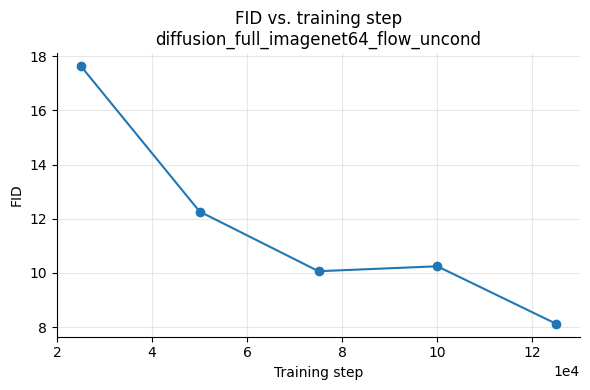

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(steps, fids, marker="o")
ax.set_xlabel("Training step")
ax.set_ylabel("FID")
ax.set_title(f"FID vs. training step\n{getattr(diff_cfg, 'experiment_name', diff_cfg.output_dir)}")
ax.grid(alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.ticklabel_format(style="sci", axis="x", scilimits=(4, 4))

plt.tight_layout()
plt.show()